<a href="https://colab.research.google.com/github/Y4G0SL/MVPDataScience/blob/main/MVP%20-%20Machine%20Learning%20%26%20Analytics/MVP2_Machine_learning_e_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# MVP - Machine Learning e Analytics
**Autor:**  Yago Soares Laguna

**Data:** 28/09/2025

**Matrícula:** 4052025001118

**Dataset:** [Salary Prediction](https://www.kaggle.com/datasets/wardabilal/salary-prediction-dataset)



---


# Descrição do Dataset
O Dataset **Salary Prediction** é um conjunto dedicado a treinamento de modelos de regressão linear, bem como para prática de visualização de dados. Este conjunto possui dados de colaboradores de diversas areas de atuação, como **Idade (age), Gênero (Gender), Educação (Education), Cargo (Job title), Anos de experiência (Years of Experience), Salário (Salary)**. <br>O conjunto conta com 6704 linhas.<br><br>
**Colunas:**

- **Age:** A idade do colaborador;

- **Gender:** Gênero do colaborador (masculino/feminino -> male/female);

- **Education:**  Maior qualificação educacional obtida pelo colaborador;

- **Job title:** Cargo atual do colaborador;

- **Years of Experience:** Tempo de experiencia total do colaborador (em anos);

- **Salary:** Salário anual do colaborador em dollars.

# Problema
Com os dados deste conjunto iremos usar o método de aprendizado supervisionado de regressão linear para estipular os salários de acordo com as caracteristicas do colaborador.

Com este modelo poderemos então predizer salários, podendo ser útil em setores de RH para definir um salário justo de acordo com as caracteristicas que a pessoa apresenta e o cargo em que ela vai atuar.


# Importação das bibliotecas e carga de dados
Nesta etapa será importada as bibliotecas a serem usadas para realizar a manipulação dos dados e será criado o dataframe que será utilizado durante o MVP.

## Bibliotecas

In [91]:
import os, random, time, sys, math, requests  # Bibliotecas utilitárias para mecher com sistema, tempo, calculos e links
import numpy as np  # numpy para manipulação e criação de arrays com performance
import pandas as pd  # pandas para manipulação dos dados do conjunto
import matplotlib.pyplot as plt  # matplot para visualização de insights em gráficos
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV, cross_validate, GridSearchCV  # Funções para treinar e testar o modelo
from sklearn.compose import ColumnTransformer  # Utilizado para aplicar outras funções nas colunas do conjunto.
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer  # Transformação dos dados na etapa de pré-processamento.
from sklearn.impute import SimpleImputer  # Utilizado para o preenchimento dos missings
from sklearn.pipeline import Pipeline  # Utilizado para montar processos de manipulação dos dados, desde pré processamento ao treinamento.
from sklearn.linear_model import Ridge, Lasso, LinearRegression  # Modelos simples para treinamento de regressão linear.
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor  # Modelos complexos para treinamento de regressão linear
from sklearn.tree import DecisionTreeRegressor  # Modelo de árvore de decisão para treinamento de regressão linear
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # Métricas de avaliação do modelo de regressão linear
from sklearn.dummy import DummyRegressor  # Modelo de baseline para comparação.
from sklearn.feature_selection import SelectKBest, f_regression  # Função para seleção de atributos.
import missingno as ms  # Biblioteca para visualização de missings
import unicodedata as ud  # Biblioteca para manipulação de strings
import re  # Biblioteca para auxiliar na manipulação de strings utilizando expressão regular
from functools import partial  # Utilizado para serializar as funções externas dentro do modelo
import seaborn as sns  # Utilizado para plots de graficos
import joblib

# Definindo a seed para reprodutibilidade
SEED = 12

# Funções para fixar a seed definida.
np.random.seed(SEED)
random.seed(SEED)

## Carga de dados e Visualização de categorias
Nesta sessão irei realizar a carga do conjunto e irei visualizar as categorias que cada variável categórica possui para ter uma noção de como posso manipular os dados e montar o pipeline posteriormente.

In [94]:
# Aplicando a uma variavel o link do conjunto para o treinamento.

dt_salarios = "https://raw.githubusercontent.com/Y4G0SL/MVPDataScience/refs/heads/main/MVP%20-%20Machine%20Learning%20%26%20Analytics/Salary_Data.csv"

# Montando o DataFrame com pandas

conjunto = pd.read_csv(dt_salarios)

# Visualizando
conjunto

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [3]:
# lista com o nome das colunas correspondentes a cada variável categórica

lista = ["Gender","Job Title","Education Level"]

# Apresenta a contagem dos valores dentro do conjunto.
for i in lista:
  print(conjunto[i].value_counts(), "\n-----------------------------")

Gender
Male      3674
Female    3014
Other       14
Name: count, dtype: int64 
-----------------------------
Job Title
Software Engineer                 518
Data Scientist                    453
Software Engineer Manager         376
Data Analyst                      363
Senior Project Engineer           318
                                 ... 
Junior Social Media Specialist      1
Senior Software Architect           1
Developer                           1
Social M                            1
Social Media Man                    1
Name: count, Length: 193, dtype: int64 
-----------------------------
Education Level
Bachelor's Degree    2267
Master's Degree      1573
PhD                  1368
Bachelor's            756
High School           448
Master's              288
phD                     1
Name: count, dtype: int64 
-----------------------------


Com essa simples verificação, pode-se notar que os dados das variaveis Job Title e Education Level tem alguns dados duplicados, com isso na etapa de pré-processamento irei tratá-los.

# Pré-processamento e Análise exploratória resumida (EDA)
Nesta etapa irei realizar a formatação dos dados e o tratamento de missings (Direcionado para análise), bem como a análise exploratória.

Irei gerar uma cópia do dataframe formatado para trabalhar com os missings de forma mais elaborada na etapa de pré-processamento com pipeline para evitar data leakage.

## Funções pré-processamento e análise
Sessão dedicada a funções para formatação dos dados. Assim os deixando mais padronizado para manipulação e análises rapidas.

In [4]:
# Retira acentos, caracteres especiais e tranforma os valores em minúsculo (utilização em colunas categóricas).

def transforma_escrita(dado):
    if pd.isna(dado):  # Caso seja um missing
        return dado

    texto = "".join(palavra for palavra in ud.normalize("NFD", dado))  # Estou utilizando ud.normalize para separar os acentos das letras
    texto = re.sub(r"[^\w\s]", "", texto)  # Utilizei a expressão [^\w\s] para substituir todos os caracteres que não são alfanuméricos
    return texto.lower().strip()


# Função para exclusão de termos dentro de string para uso em dataframes

def excluir_termos(dado, palavras_chave):
    if pd.isna(dado):  # Caso seja um missing
        return dado

    for palavra in palavras_chave:
        dado = dado.replace(palavra, "")  # Substitui a palavra por vazio.
    return dado.strip()  # Retira os espaços em branco.


# Função para excluir as linhas que são totalmente nulas

def exclui_total_nula(df):
    df = df.dropna(how="all")  # Exclui todas as linhas do dataframe que contenham nulos em todas as colunas
    return df  # Retorna o dataframe sem as linhas nulas


# Função com os termos constantes nos dados de "Job Title" que indicam senioridade, para atribuição de pesos aos cargos definidos
# a função retorna o valor referente ao termo encontrado dentro do dado. Sendo 2 para os cargos operacionais que geralmente a pessoa
# ganha experiencia de acordo com a atuação, assim podendo ter bastante ou pouca experiencia no mesmo cargo não afetando o seu salário com isso.

def adiciona_nivel_senior(dado):
    level_1 = ['junior', 'juniour']

    level_3 = ['senior', 'principal', 'consultant', 'specialist', 'architect', 'advisor', 'researcher']

    level_4 = ['manager', 'director', 'vp', 'chief', 'coordinator', 'lead', 'ceo']

    if re.search('|'.join(level_1), dado):
        return 1
    elif re.search('|'.join(level_3), dado):
        return 3
    elif re.search('|'.join(level_4), dado):
        return 4
    else:
        return 2


# Função de tranformação de valores das colunas com variaveis categoricas ordinais, tranforma a coluna em números de acordo com o peso.

def transforma_categoria(dado, dict_categorias):
    if pd.isna(dado):
        return dado

    if dado in dict_categorias:
        return dict_categorias[dado]
    else:
        return dado






## Pré-processamento e análise
Sessão dedicada a encontrar meios de tratamento para os dados e insights para ajudar na escolha dos parâmetros e criação dos pipelines posteriormente.



In [5]:
# Criando uma cópia do conjunto original para análise
conjunto_pre = conjunto.copy()
conjunto_pre[["Job Title", "Education Level", "Gender"]] = conjunto_pre[["Job Title", "Education Level", "Gender"]].map(transforma_escrita)  # Aplicando a função de padronização de escrita(retira caracteres especiais e acentos e então retorna em minúsculo) nas colunas categóricas
conjunto_pre

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,male,bachelors,software engineer,5.0,90000.0
1,28.0,female,masters,data analyst,3.0,65000.0
2,45.0,male,phd,senior manager,15.0,150000.0
3,36.0,female,bachelors,sales associate,7.0,60000.0
4,52.0,male,masters,director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,female,phd,director of marketing,20.0,200000.0
6700,32.0,male,high school,sales associate,3.0,50000.0
6701,30.0,female,bachelors degree,financial manager,4.0,55000.0
6702,46.0,male,masters degree,marketing manager,14.0,140000.0


Antes de continuar irei excluir as linhas que todos os dados são nulos.

In [6]:
# Utilizando a função criada para a exclusão das linhas que sejam totalmente nulas
conjunto_pre_1 = conjunto_pre.copy()  # Criando uma cópia para evitar warnings
conjunto_pre_1 = exclui_total_nula(conjunto_pre_1)

In [7]:
# Realizando a contagem novamente dos valores dessa vez incluindo os missings

for i in lista:
  print(conjunto_pre[i].value_counts(dropna=False), "\n-----------------------------")

Gender
male      3674
female    3014
other       14
NaN          2
Name: count, dtype: int64 
-----------------------------
Job Title
software engineer                     518
data scientist                        453
software engineer manager             376
data analyst                          363
senior project engineer               318
                                     ... 
junior social media specialist          1
senior product development manager      1
developer                               1
social m                                1
social media man                        1
Name: count, Length: 193, dtype: int64 
-----------------------------
Education Level
bachelors degree    2267
masters degree      1573
phd                 1369
bachelors            756
high school          448
masters              288
NaN                    3
Name: count, dtype: int64 
-----------------------------


Irei trabalhar na variavel "Job Title" para excluir as informações redundantes. Primeiro irei capturar todas as variações da variável para poder ver a possibilidade de criação de uma variável que indique a senioridade do cargo

In [8]:
# Extraindo os termos para realizar a analise de indicadores de senioridade como senior, junior, manager...
# Através disso irei criar uma função para criação de uma nova coluna, no dataset.

conjunto_pre_1["Job Title"].unique()

array(['software engineer', 'data analyst', 'senior manager',
       'sales associate', 'director', 'marketing analyst',
       'product manager', 'sales manager', 'marketing coordinator',
       'senior scientist', 'software developer', 'hr manager',
       'financial analyst', 'project manager', 'customer service rep',
       'operations manager', 'marketing manager', 'senior engineer',
       'data entry clerk', 'sales director', 'business analyst',
       'vp of operations', 'it support', 'recruiter', 'financial manager',
       'social media specialist', 'software manager', 'junior developer',
       'senior consultant', 'product designer', 'ceo', 'accountant',
       'data scientist', 'marketing specialist', 'technical writer',
       'hr generalist', 'project engineer', 'customer success rep',
       'sales executive', 'ux designer', 'operations director',
       'network engineer', 'administrative assistant',
       'strategy consultant', 'copywriter', 'account manager',
      

Após realizar a análise, utilizei IA(Copilot) para extração dos termos, como utilizei IA poderia ter criado alguma NLP e utilizar algum modelo não supervisionado para realizar a busca automática e agrupamento. Para o MVP o deixaria muito complexo, porém para uma empresa seria necessário.

Seguindo em frente irei criar a coluna indicativa para senioridade.

In [9]:
# Aplicando a função para a criação da coluna/variavel que indica a senioridade de cada cargo com pesos.
conjunto_pre_2 = conjunto_pre_1.copy()  # Criando uma cópia para evitar warnings

conjunto_pre_2["Seniority"] = conjunto_pre_2["Job Title"].apply(adiciona_nivel_senior)

conjunto_pre_2

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Seniority
0,32.0,male,bachelors,software engineer,5.0,90000.0,2
1,28.0,female,masters,data analyst,3.0,65000.0,2
2,45.0,male,phd,senior manager,15.0,150000.0,3
3,36.0,female,bachelors,sales associate,7.0,60000.0,2
4,52.0,male,masters,director,20.0,200000.0,4
...,...,...,...,...,...,...,...
6699,49.0,female,phd,director of marketing,20.0,200000.0,4
6700,32.0,male,high school,sales associate,3.0,50000.0,2
6701,30.0,female,bachelors degree,financial manager,4.0,55000.0,4
6702,46.0,male,masters degree,marketing manager,14.0,140000.0,4


In [10]:
# Irei aplicar a função de exclusão de termos para excluir termos que indicam senioridade junior, senior para reduzir a dimensão de categorias ja que estas não compõem o nome do cargo em si.
conjunto_pre_3 = conjunto_pre_2.copy()  # Criando uma cópia para evitar warnings

conjunto_pre_3["Job Title"] = conjunto_pre_3["Job Title"].apply(excluir_termos, args=[["junior", "juniour", "senior"]])

conjunto_pre_3

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Seniority
0,32.0,male,bachelors,software engineer,5.0,90000.0,2
1,28.0,female,masters,data analyst,3.0,65000.0,2
2,45.0,male,phd,manager,15.0,150000.0,3
3,36.0,female,bachelors,sales associate,7.0,60000.0,2
4,52.0,male,masters,director,20.0,200000.0,4
...,...,...,...,...,...,...,...
6699,49.0,female,phd,director of marketing,20.0,200000.0,4
6700,32.0,male,high school,sales associate,3.0,50000.0,2
6701,30.0,female,bachelors degree,financial manager,4.0,55000.0,4
6702,46.0,male,masters degree,marketing manager,14.0,140000.0,4


In [11]:
# Conferindo a distribuição de cargos

conjunto_pre_3['Job Title'].value_counts(dropna=False)

,count
Job Title,
software engineer,813
data scientist,515
data analyst,391
software engineer manager,376
product manager,323
...,...
advertising coordinator,1
hr specialist,1
software architect,1


Pode-se notar que se reduziu a quantidade de cargos, com isso irei seguir para a correção dos niveis de formação

In [12]:
# Excluindo o termo degree constante em algumas situações para unificar os valores.
conjunto_pre_4 = conjunto_pre_3.copy()  # Criando uma cópia para evitar warnings

conjunto_pre_4["Education Level"] = conjunto_pre_4["Education Level"].apply(excluir_termos, args=[[" degree"]])

conjunto_pre_4

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Seniority
0,32.0,male,bachelors,software engineer,5.0,90000.0,2
1,28.0,female,masters,data analyst,3.0,65000.0,2
2,45.0,male,phd,manager,15.0,150000.0,3
3,36.0,female,bachelors,sales associate,7.0,60000.0,2
4,52.0,male,masters,director,20.0,200000.0,4
...,...,...,...,...,...,...,...
6699,49.0,female,phd,director of marketing,20.0,200000.0,4
6700,32.0,male,high school,sales associate,3.0,50000.0,2
6701,30.0,female,bachelors,financial manager,4.0,55000.0,4
6702,46.0,male,masters,marketing manager,14.0,140000.0,4


In [13]:
# Contagem dos valores de educação

conjunto_pre_4['Education Level'].value_counts(dropna=False)

,count
Education Level,
bachelors,3023
masters,1861
phd,1369
high school,448
NaN,1


Irei tratar os missings começando pelas linhas que não tenham o valor na coluna "Salary"

In [14]:
# Realiza a filtragem para ver os missings restantes
filtro = conjunto_pre_4.isnull().any(axis=1)
conjunto_pre_4[filtro]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Seniority
2011,27.0,male,NaN,developer,7.0,100000.0,2
3136,31.0,male,masters,full stack engineer,8.0,NaN,2
5247,26.0,female,bachelors,social m,NaN,NaN,2
6455,36.0,male,bachelors,sales director,6.0,NaN,4


In [15]:
# Excluindo as linhas que tem nulo em "Salary" e visualizando o que sobrou

conjunto_pre_5 = conjunto_pre_4.copy()  # Criando uma cópia para evitar warnings

conjunto_pre_5 = conjunto_pre_5.dropna(subset=["Salary"])

filtro = conjunto_pre_5.isnull().any(axis=1)
conjunto_pre_5[filtro]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Seniority
2011,27.0,male,NaN,developer,7.0,100000.0,2


In [16]:
# Adicionando o valor mais frequente ao missing da coluna "Education Level" e visualizando os missings
conjunto_pre_6 = conjunto_pre_5.copy()  # Criando uma cópia para evitar warnings

valor = conjunto_pre_6["Education Level"].mode()[0]  # Capturando o valor com mais frequência dentro da coluna

conjunto_pre_6.fillna({"Education Level": valor}, inplace=True)  # Preenchendo todos os nulos com o valor mais frequente

conjunto_pre_6[conjunto_pre_6.isnull().any(axis=1)]  # Exibindo as linhas com valor nulo

,Age,Gender,Education Level,Job Title,Years of Experience,Salary,Seniority


Com o tratamento de missings concluído irei gerar algumas breves análises. Mas antes vou tranformar os dados em números com OneHotEncoder para gêneros e a função criada para atribuir pesos as variaveis de "Education Level", e TargetEncoder para a variavel nominal tranformando cada cargo em sua frequência.

In [17]:
# Criando uma copia do dataframe anterior para melhor manipulação
conjunto_pre_7 = conjunto_pre_6.copy()  # Criando uma cópia para evitar warnings

# Tranformando os dados de gênero em colunas com True e False.
conjunto_pre_7 = pd.get_dummies(conjunto_pre_7, columns=["Gender"])

# Tranformando os valores True e False para números, sendo 1 para True e 0 para False
conjunto_pre_7[["Gender_male", "Gender_female", "Gender_other"]] = conjunto_pre_7[["Gender_male", "Gender_female", "Gender_other"]].astype(int)

# Atribuindo os pesos para variavel "Education Level"
conjunto_pre_7["Education Level"] = conjunto_pre_7["Education Level"].apply(transforma_categoria, args=[{"high school": 1, "bachelors": 2, "masters": 3, "phd": 4}])

# Substituindo os valores de "Job Title" pela sua freuquencia de aparição.
conjunto_pre_7["Job Title"] = conjunto_pre_7["Job Title"].apply(lambda x: conjunto_pre_7["Job Title"].value_counts()[x])

# Exibindo o conjunto
conjunto_pre_7

,Age,Education Level,Job Title,Years of Experience,Salary,Seniority,Gender_female,Gender_male,Gender_other
0,32.0,2,813,5.0,90000.0,2,0,1,0
1,28.0,3,391,3.0,65000.0,2,1,0,0
2,45.0,4,2,15.0,150000.0,3,0,1,0
3,36.0,2,212,7.0,60000.0,2,1,0,0
4,52.0,3,1,20.0,200000.0,4,0,1,0
...,...,...,...,...,...,...,...,...,...
6699,49.0,4,88,20.0,200000.0,4,1,0,0
6700,32.0,1,212,3.0,50000.0,2,0,1,0
6701,30.0,2,139,4.0,55000.0,4,1,0,0
6702,46.0,3,315,14.0,140000.0,4,0,1,0


In [18]:
# Criando o conjunto de análise com os tratamentos e dados tranformados
conjunto_analise = conjunto_pre_7.copy()

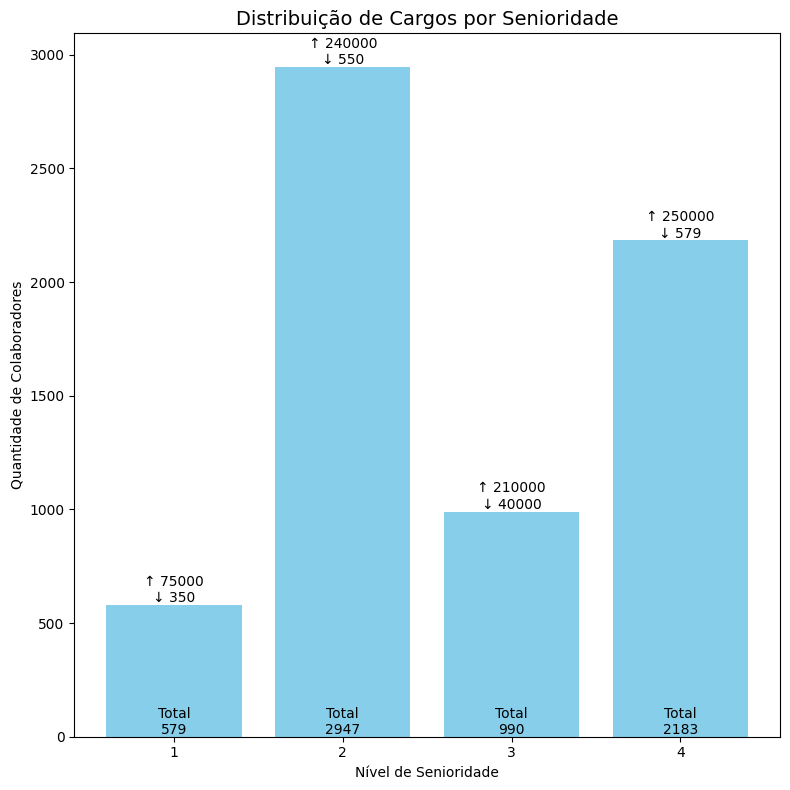

In [19]:
# Plotando a quantidade de colaboradores por senioridade com maior e menor salário no topo de cada barra.
conjunto_agrupado = conjunto_analise.groupby("Seniority")  # Agrupando o conjunto pela coluna "Seniority"
contagem = conjunto_agrupado["Job Title"].count()  # Realizando a contagem de cargos em cada nivel de "Seniority"
salario_max = conjunto_agrupado["Salary"].max()  # Capturando o valor máximo de salário
salario_min = conjunto_agrupado["Salary"].min()  # Capturando o valor minimo de salário

fig, ax = plt.subplots(figsize=(8, 8))  # Configurando o grafico com 8 de altura e 8 de largura
barras = ax.bar(contagem.index.astype(str), contagem.values, color="skyblue")  # Configurando as barras do gráfico com os valores de contagem

# Adicionar os salários no topo de cada barra e os totais na base
for i, barra in enumerate(barras):
    nivel = contagem.index[i]  # Capturando o nivel nesta variavel
    max_sal = salario_max[nivel]  # Salario maximo do nivel
    min_sal = salario_min[nivel]  # Salario minimo do nivel
    texto = f"↑ {max_sal:.0f}\n↓ {min_sal:.0f}"  # Texto a ser inserido acima de cada barra
    ax.text(barra.get_x() + barra.get_width()/2, # Posição horizontal na barra, pego a posição horizontal da barra no grafico e adiciono mais a metade de sua largura.
            barra.get_height(),  # Posição vertical do texto, pego a altura da barra apenas
            texto,  # Texto definido anteriormente na barra.
            ha='center',  # Alinhamento horizontal definido como central
            va='bottom',  # Alinhamento vertical definido como base
            fontsize=10,   # Tamanho da fonte
            color='black')  # Cor da fonte

    # Adicionando os totais na base de cada barra

    valor = barra.get_height()  # Valor total do nivel, presente na altura total da barra.
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        0,  # posição vertical na base
        f'Total\n{int(valor)}',  # Texto a ser inserido.
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

ax.set_title('Distribuição de Cargos por Senioridade', fontsize=14)  # Configurando o titulo
ax.set_xlabel('Nível de Senioridade')  # configurando o rotulo de baixo, eixo X.
ax.set_ylabel('Quantidade de Colaboradores')  # configurando o rótulo da lateral, eixo Y

plt.tight_layout()
plt.show()

Através do plot foi possivel perceber que o nivel de senioridade 2, em sua maioria cargos operacionais e cargos com nomeações comuns, possui a maior contagem de colaboradores dentro do conjunto bem como um salário máximo que chega próximo ao do nivel 4.

<Axes: >

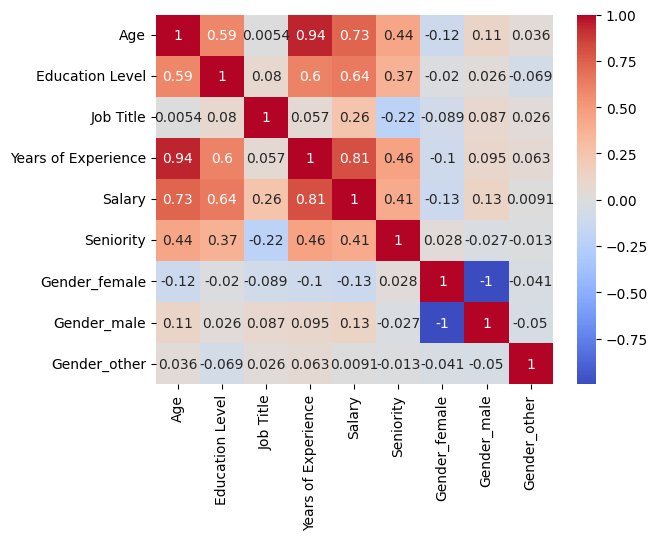

In [20]:
# Exibindo a correlação das variáveis
sns.heatmap(conjunto_analise.corr(), annot=True, cmap='coolwarm')

Através da análise de correlação pode-se notar que as variáveis que realmente influenciam no valor do salario são: **Age**, **Education level**, **job title**, **Years of Experience** e **Seniority**, o gênero masculino também porém as variaveis de gênero serão desconsideradas pois a influencia não é muito relevente. Por outro lado **Age** e **Years of Experience** tem grande influência porém as duas tem alta correlação entre si, então para não considerar o mesmo peso de variável (No caso o tempo nessas duas variáveis) provavelmente depois de testes irei excluir **Age** do treinamento do modelo e deixar apenas **Years of Experience** já que tem o mesmo sentido que **Age**, porém maior correlação com **Salary**. Irei iniciar agora a definição e treinamento do modelo de regressão linear.

# Definição e treinamento do modelo de regressão linear
Nesta etapa irei definir e realizar uma série de testes com os modelos de regressão linear utilizando desde alguns modelos simples a ensembles mais complexos para tentar atingir uma boa acurácia e definição de parâmetros.


## Funções para pipeline
Nesta primeira sessão desta etapa adaptarei algumas funções utilizadas na etapa anterior.

In [21]:
# Função para excluir as linhas que são totalmente nulas

def exclui_total_nula(df):
    df = df.dropna(how="all")  # Exclui todas as linhas do dataframe que contenham nulos em todas as colunas
    return df  # Retorna o dataframe sem as linhas nulas


# Função para avaliação do modelo de regressão linear, retornando um dicionário com as metricas de avaliação.

def avaliar_modelo(nome, modelo, X, y):
    resultados = cross_validate(
        modelo,
        X,
        y,
        cv=5,
        scoring=["neg_mean_squared_error", "neg_mean_absolute_error", "r2"]
    )

    mse = -resultados["test_neg_mean_squared_error"].mean()
    mae = -resultados["test_neg_mean_absolute_error"].mean()
    rmse = np.sqrt(mse)
    r2 = resultados["test_r2"].mean()

    return {
        "Modelo": nome,
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2),
        "R²": round(r2, 2)
    }


## Criação do pipeline e divisão dos dados
Nesta seção será criado o pipeline para tranformação dos dados e o ajuste do conjunto para o treinamento do modelo o dividindo em treino e teste.

In [36]:
# Removendo as linhas que não serão usadas no dataset.
# Como no pipeline não é possivel remoção de linhas por causa da necessidade de dimensionalidade estática excluirei agora.

# Criando uma cópia do conjunto original sem as tranformações do conjunto de análise
conjunto_modelo = conjunto.copy()

# Excluindo todos os dados que sejam totalmente nulos ou que tenham valores nulos em "Salary"
conjunto_modelo = exclui_total_nula(conjunto_modelo)
conjunto_modelo = conjunto_modelo[conjunto_modelo["Salary"].notna()]

# Criando a variavel Seniority pois assim como o pipeline não retira ele também não insere informações
conjunto_modelo["Seniority"] = conjunto_modelo["Job Title"].apply(adiciona_nivel_senior)


# Formatando a escrita com a função utilizada no pre processamento
conjunto_modelo[["Education Level", "Gender", "Job Title"]] = conjunto_modelo[["Education Level", "Gender", "Job Title"]].map(transforma_escrita)

# Formatando os niveis de educação
conjunto_modelo['Education Level'] = conjunto_modelo["Education Level"].apply(excluir_termos, args=[[" degree"]])

# Formatando os titulos dos cargos
conjunto_modelo['Job Title'] = conjunto_modelo['Job Title'].apply(excluir_termos, args=[["junior", "juniour", "senior"]])

# Aplicando os pesos na variavel education

conjunto_modelo["Education Level"] = conjunto_modelo["Education Level"].apply(transforma_categoria, args=[{"high school": 1, "bachelors": 2, "masters": 3, "phd": 4}])

# Aplicando a tranformação por contagem de ocorrências em Job Title

conjunto_modelo["Job Title"] = conjunto_modelo["Job Title"].apply(lambda x: conjunto_modelo["Job Title"].value_counts()[x])

In [64]:
# Dividindo o conjunto de dados em treino e teste

X = conjunto_modelo.drop(columns=["Salary"])  # Features
y = conjunto_modelo["Salary"]  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

In [65]:
# Criando as etapas para o pipeline

# Ajusta os missings da coluna Gender e aplicação do One Hot Encoding
missing_gender = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocessamento do baseline para utilizações em testes de modelos
preprocessamento_baseline = ColumnTransformer([
    ("imputa_cat", SimpleImputer(strategy="most_frequent"), ["Job Title", "Education Level"]),
    ("imputa_num", SimpleImputer(strategy="mean"), ["Age", "Years of Experience"])
], remainder="drop")



In [69]:
# Preprocessamentos para definição de melhores atributos

# Todos os atributos
preprocessamento_modelo_1 = ColumnTransformer([
    ("missings_cat", SimpleImputer(strategy="most_frequent"), ["Job Title", "Education Level", "Seniority"]),
    ("missings_gender", missing_gender, ["Gender"]),
    ("missings_num", SimpleImputer(strategy="mean"), ["Age", "Years of Experience"])
], remainder="drop")

# Sem atributo Gender
preprocessamento_modelo_2 = ColumnTransformer([
    ("missings_cat", SimpleImputer(strategy="most_frequent"), ["Job Title", "Education Level", "Seniority"]),
    ("missings_num", SimpleImputer(strategy="mean"), ["Age", "Years of Experience"])
], remainder="drop")

# Sem atributo Age e Gender
preprocessamento_modelo_3 = ColumnTransformer([
    ("missings_cat", SimpleImputer(strategy="most_frequent"), ["Job Title", "Education Level", "Seniority"]),
    ("missings_num", SimpleImputer(strategy="mean"), ["Years of Experience"])
], remainder="drop")

In [95]:
# Aplicando SelectKBest para ver quais atributos são os melhores

# Definindo o seletor para os atributos trabalhados
seletor = SelectKBest(score_func=f_regression, k=4)

# Aplicando o seletor dentro do pipeline
pipeline_seletor = Pipeline([
    ("preprocessamento", preprocessamento_modelo_1),
    ("scaler", StandardScaler()),
    ("seletor", seletor)
])

# Passando os dados para o pipeline
pipeline_seletor.fit(X_train, y_train)

# Extraindo os nomes das features após o preprocessamento
nomes_transformados = pipeline_seletor.named_steps["preprocessamento"].get_feature_names_out()

# Pegando os scores de cada atributo
scores = seletor.scores_

# Atribuindo os resultados a um dataframe
df_scores = pd.DataFrame({
    "Feature": nomes_transformados,
    "Score": scores
}).sort_values(by="Score", ascending=False)

df_scores.head(10)

,Feature,Score
7,missings_num__Years of Experience,10109.368389
6,missings_num__Age,5945.177780
1,missings_cat__Education Level,3712.310619
0,missings_cat__Job Title,392.764099
3,missings_gender__Gender_female,91.514835
4,missings_gender__Gender_male,91.252836
5,missings_gender__Gender_other,0.014738
2,missings_cat__Seniority,0.000000


Aparentemente a maioria dos atributos possuem um score bom, irei treinar os modelos com eles.

In [75]:
# Definindo scores de uma baseline com os dados iniciais de uso e os modelos

modelos = {
    "Baseline": DummyRegressor(strategy="mean"),  # Modelo de baseline para medida de desempenho minimo
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(random_state=SEED),
    "Random Forest": RandomForestRegressor(random_state=SEED),
    "Gradient Boosting": GradientBoostingRegressor(random_state=SEED),
    "Ridge": Ridge(random_state=SEED),
    "Lasso": Lasso(random_state=SEED)
}

avaliacoes = []  # Variavel para armazenar as informações de metricas

# Iteração para calcular as mátricas dos vários modelos utilizando preprocessamento basico
for nome, modelo in modelos.items():
    pipeline = Pipeline([  # Pipeline com preprocessamento básico e definição do modelo
        ("preprocessamento", preprocessamento_baseline),
        ("modelo", modelo)
    ])

    resultado = avaliar_modelo(nome, pipeline, X_train, y_train)  # Utilizando a função que criei para avaliação dos modelos de regressão
    avaliacoes.append(resultado)  # Adicionando os resultados a lista

# Montando um dataframe com as avaliações e ordenando-os com base no RMSE
df_resultados = pd.DataFrame(avaliacoes)
df_resultados.sort_values(by="RMSE")

,Modelo,MSE,RMSE,MAE,R²
3,Random Forest,8.222341e+07,9067.71,3942.52,0.97
2,Árvore de Decisão,1.082408e+08,10403.88,3925.62,0.96
4,Gradient Boosting,2.334717e+08,15279.78,11080.88,0.92
1,Regressão Linear,7.350310e+08,27111.46,21360.56,0.74
6,Lasso,7.350311e+08,27111.46,21360.69,0.74
5,Ridge,7.350310e+08,27111.46,21360.95,0.74
0,Baseline,2.813635e+09,53043.71,46002.69,-0.00


Visualizando a tabela pode-se notar que há 3 modelos com bom desempenho RandomForest, Arvore de decisão e gradient boosting, este último pode ser que tenha ocorrido overfitting devido ao erro absoluto (MAE) alto. Irei prosseguir com o aprimoramento do RandomForest e ver se consigo melhorá-lo.

In [80]:
# Utilizarei GridSearch para avaliar os melhores parâmetros
# Definindo o modelo
modelo_rf = RandomForestRegressor(random_state=SEED)

# Definindo os parâmetros e seus valores
parametros_rf = {
    "n_estimators": [100, 200, 300],  # Numero de arvores
    "max_depth": [None, 10, 20, 30],  # Profundidade de ramificação máxima
    'min_samples_split': [2, 5, 10],  # Minimo de de amostras para dividir um nó
    'min_samples_leaf': [1, 2, 4]  # Minimos de amostras que uma folha comporta
}

# Criando o pipeline
pipeline = Pipeline([
    ("preprocessamento", preprocessamento_modelo_1),
    ("modelo", modelo_rf)
])

# Utilizando GridSearchCV para testar os melhores parâmetros.
grid_rf = GridSearchCV(pipeline, {"modelo__" + param: val for param, val in parametros_rf.items()}, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessamento',
                                        ColumnTransformer(transformers=[('missings_cat',
                                                                         SimpleImputer(strategy='most_frequent'),
                                                                         ['Job '
                                                                          'Title',
                                                                          'Education '
                                                                          'Level',
                                                                          'Seniority']),
                                                                        ('missings_gender',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Gender']),
                                                                        ('missings_num',
                                                                         SimpleImputer(),
                                                                         ['Age',
                                                                          'Years '
                                                                          'of '
                                                                          'Experience'])])),
                                       ('modelo',
                                        RandomForestRegressor(random_state=12))]),
             n_jobs=-1,
             param_grid={'modelo__max_depth': [None, 10, 20, 30],
                         'modelo__min_samples_leaf': [1, 2, 4],
                         'modelo__min_samples_split': [2, 5, 10],
                         'modelo__n_estimators': [100, 200, 300]},
             scoring='neg_mean_squared_error')

In [81]:
# Exibindo os melhores parâmetros e sua métrica

print("Melhores parâmetros:", grid_rf.best_params_)
print("Melhor RMSE:", (-grid_rf.best_score_)**0.5)

Melhores parâmetros: {'modelo__max_depth': None, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 200}
Melhor RMSE: 8538.27164622804


É possível ver uma melhora no desempenho do modelo com os melhores parâmetros escolhidos. Como demorou em torno de 11 minutos para achar a melhor otimização irei exportá-lo.

In [84]:
# Usando joblib para exportar o modelo

# joblib.dump(grid_rf.best_estimator_, "modelo_random_forest_otimizado.pkl")

['modelo_random_forest_otimizado.pkl']

Adicionei o modelo no github para poder usá-lo sem executar o treinamento novamente

In [89]:
# Carregando o modelo otimizado

# Utilizando requests para acessar o link e capturar o conteúdo (Caso o link seja acessado diretamente, o download inicia automaticamente)
response = requests.get("https://github.com/Y4G0SL/MVPDataScience/raw/refs/heads/main/MVP%20-%20Machine%20Learning%20&%20Analytics/modelo_random_forest_otimizado.pkl")

# Gravando o arquivo pickle no repositório local do colab
with open("modelo_random_forest_otimizado.pkl", "wb") as f:
    f.write(response.content)  # Escrevendo o conteúdo do link no arquivo

modelo_otimizado = joblib.load("modelo_random_forest_otimizado.pkl")  # Carregando o modelo

Vou começar as predições para teste e gerar análises de erro para ver como realmente está o modelo.

In [90]:
# Predizendo os salários com a base teste
y_pred = modelo_otimizado.predict(X_test)

In [92]:
# Gerando metricas para avaliação do desempenho

mse = mean_squared_error(y_test, y_pred)  # Realizando os calculos para a metrica de mean squared error
rmse = np.sqrt(mse)  # Realizando os calculos para a metrica de root mean squared error
mae = mean_absolute_error(y_test, y_pred)  # Realizando os calculos para a metrica de mean absolute error
r2 = r2_score(y_test, y_pred)  # Realizando os calculos para a metrica do coeficiente de determinação

# Mostrando os resultados
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

RMSE: 9723.15
MAE: 3668.37
R²: 0.96


As métricas estão consideravelmente boas considerando que utilizei todas as variáveis e não exclui nenhuma, como os salários são anuais em sua maioria passa dos 100000(cem mil) em quantidade uma taxa de erro de em torno de 9700 (indicado pelo RMSE) pode ser considerado baixa. Outra metrica que se destaca é o coeficioente de determinação que indica que o modelo atende a quase todas as variações que é apresentado no conjunto. A seguir irei visualizar a distribuição dos erros.

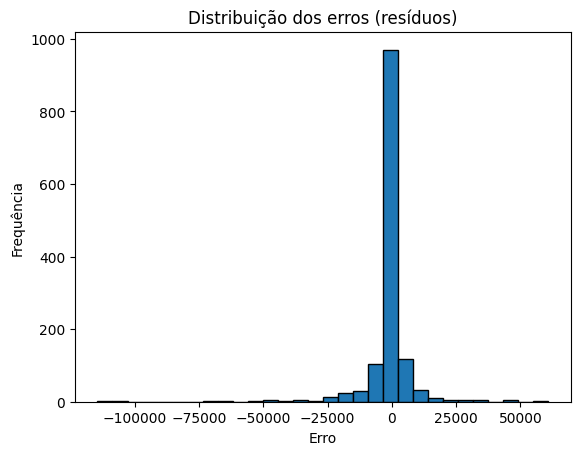

In [93]:
# Analisando os resíduos do modelo e com que frequência isso ocorre

# Gerando os dados de erro para o plot
residuos = y_test - y_pred

plt.hist(residuos, bins=30, edgecolor='black')  # Usando um histograma para a visualização
plt.title("Distribuição dos erros (resíduos)")  # Definindo título
plt.xlabel("Erro")  # Definindo rótulo do eixo X
plt.ylabel("Frequência")  # Definindo rótulo do eixo Y
plt.show()

De acordo com o gráfico o modelo está muito bom com erro em torno de zero em sua maioria, e que há uma simetria em torno dos valores o que pode indicar que o conjunto de teste pode conter outliers.

**Limitações:**
De acordo com o gráfico de distribuição de erros o modelo está generalizando bem, porém pode ser que para casos raros/outliers ele tenha mais chance de maior erro pois o conjunto pode não apresentar tantos exemplos dos dados para melhor predição.

## Conclusão

**Meu desempenho geral:** Durante a produção do MVP não tive tantas dificuldades para manipular o conjunto escolhido, porém tive mais trabalho de elaborar estratégias para indicar que os cargos("Job Title") possuiam peso em relação ao salário já que a variação de cargos é bem alta.

**Dificuldades:** Durante a parte de pré processamento e análise fui anotando os caminhos de transformações que eu realizei para aplicar posteriormente em um pipeline e então automatizar tudo, porém notei que pipelines não funcionam do jeito que eu achei que deveriam, eles realizam tranformações nos dados, porém não pode ser baseado no valor em especifico do dado e sim em algo geral para o conjunto como quantidade de variações de categoria ou calculos associados a essas caracteristicas. Com isso mudei a minha estratégia de uso dos pipelines para algo mais padrão como OneHot para dados de baixa cardinalidade e outras estratégias para variáveis com alta cardinalidade.
<br>
<br>
**O que poderia melhorar o modelo?** O conjunto utilizado tem em torno de 6000 linhas com bastante variações e cargos, porém tem poucos dados de determinados cargos o que faz o modelo ter mais chances de errar quando avalia um desses, ter mais dados com uma distribuição com boa quantidade de cada cargo pode fazer o modelo ter um desempenho muito melhor.Em relação a sua precisão uma coluna nativa referente a senioridade do cargo poderia trazer mais precisão para o significado da variável já que atualmente o modelo conta com uma estimativa baseado em termos.

**Como melhorar o projeto:** A criação de um modelo de processamento de linguagem natural poderia realizar as buscas pelos termos que indicam senioridade e junto de um modelo de agrupamento definir grupos para cada cargo. Com isso automatizando esta tarefa.